In [76]:
#importing nwcessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
#loading the dataset
df=pd.read_csv(("../Dataset/customer_churn_prediction_dataset.csv")
)

In [78]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


In [79]:
#checking the no:of rows and columns of the dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 300 rows and 21 columns


In [80]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.000000,300.000000,300.000000,300.000000
mean,0.543333,35.783333,67.226800,2477.975767
std,0.498951,21.113400,28.638073,1918.540111
min,0.000000,1.000000,18.450000,30.030000
25%,0.000000,17.000000,42.337500,910.302500
50%,1.000000,36.000000,68.635000,2072.400000
75%,1.000000,53.250000,92.430000,3618.405000
max,1.000000,72.000000,118.640000,8318.880000


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    object 
 7   MultipleLines     300 non-null    object 
 8   InternetService   300 non-null    object 
 9   OnlineSecurity    300 non-null    object 
 10  OnlineBackup      300 non-null    object 
 11  DeviceProtection  300 non-null    object 
 12  TechSupport       300 non-null    object 
 13  StreamingTV       300 non-null    object 
 14  StreamingMovies   300 non-null    object 
 15  Contract          300 non-null    object 
 16  PaperlessBilling  300 non-null    object 
 1

Majority of the features in the datapoints is categorical




In [82]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There are no null values in the dataset

In [83]:
print(df['gender'].value_counts())

gender
Male      151
Female    149
Name: count, dtype: int64


The dataset have data of 151 Males and 149 Females

In [84]:
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
1    163
0    137
Name: count, dtype: int64


Out of 300 customers,163 are senior citizens

In [85]:
print(df['Partner'].value_counts())

Partner
Yes    155
No     145
Name: count, dtype: int64


155 customers have partners and 145 customers are single

In [86]:
print(df['Dependents'].value_counts())

Dependents
Yes    158
No     142
Name: count, dtype: int64


158 customers have dependents and 148 doesn't


In [87]:
df['tenure'].mean()

np.float64(35.78333333333333)

On an average, A customer stays with the company for 35 months

In [88]:
print(f" A non - senior citizen stays with the company for {(df[df['SeniorCitizen']==0]['tenure']).mean()} months and a senior citizen {(df[df['SeniorCitizen']==1]['tenure']).mean()} months")

 A non - senior citizen stays with the company for 36.583941605839414 months and a senior citizen 35.11042944785276 months


In [89]:
df['Contract'].value_counts()

Contract
Month-to-month    111
One year           97
Two year           92
Name: count, dtype: int64

In [90]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    164
No     136
Name: count, dtype: int64

164 customers use paperless billing and 136 paperless

In [91]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check    77
Bank transfer       76
Credit card         74
Mailed check        73
Name: count, dtype: int64

Equal distribution of customers using electronic check,bank transfer,credit card and mailed check

**Visualisation**

<Axes: xlabel='TotalCharges', ylabel='Count'>

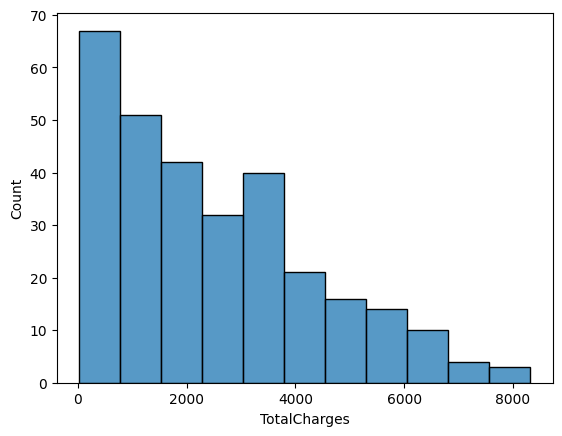

In [92]:
sns.histplot(df['TotalCharges'])

<Axes: ylabel='TotalCharges'>

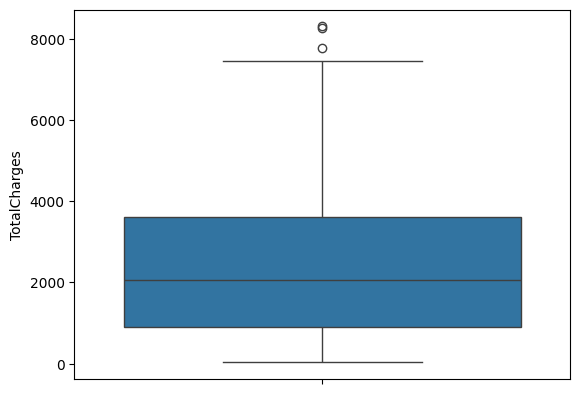

In [94]:
sns.boxplot(df['TotalCharges'])

In [95]:
df['MonthlyCharges']

0       27.43
1       38.28
2      106.44
3       92.49
4       19.63
        ...  
295     42.52
296     22.31
297     59.57
298     31.32
299     20.50
Name: MonthlyCharges, Length: 300, dtype: float64